<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/iLogos/logo_novafct.png" width="200">

# Departamento de Engenharia Mecânica e Industrial
## Mecânica dos Sólidos II

## Análise e projeto de vigas sujeitas à flexão. Diagramas de esforços internos.

### Problema 1

Sabendo que o varão ABC de secção circular com 20 mm de diâmetro está em equilíbrio sob a ação do carregamento indicado, desenhe os diagramas do esforço transverso e do momento fletor e determine a tensão normal máxima devida à flexão.

<img src="https://userweb.fct.unl.pt/~jmc.xavier/MSII/Notebooks/Au04/P1/MSII_Au04_P1.png"
style="max-height: 100%; max-width: 100%;"/>

#### Dados do problema

In [63]:
import numpy as np
import sympy as sy
from sympy.solvers import solve
import matplotlib.pyplot as plt
import os

cor = '2'
if cor == '1':
    plt.rcParams['axes.facecolor'] = (.15, .15, .15)
    plt.rcParams['figure.facecolor'] = (.15, .15, .15)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.8, .8, .8),
              "xtick.color" : (.8, .8, .8),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.7, .7, .7),
              "axes.labelcolor" : (.8, .8, .8),
              "axes.edgecolor" : (.15, .15, .15)}
else:
    plt.rcParams['axes.facecolor'] = (.7, .7, .7)
    plt.rcParams['figure.facecolor'] = (.7, .7, .7)
    plt.rcParams['font.family'] = 'monospace'
    plt.rcParams['font.size'] = 18
    # plt.rcParams['text.usetex'] = True
    params = {"ytick.color" : (.1, .1, .1),
              "xtick.color" : (.1, .1, .1),
              "grid.color" : (.2, .2, .2),
              "text.color" : (.1, .1, .1),
              "axes.labelcolor" : (.1, .1, .1),
              "axes.edgecolor" : (.15, .15, .15)}
plt.rcParams.update(params)

# data structure, units: N, m, Pa
# Create an empty class
class varin: pass

dados = varin()
dados.Q = 750. # N/m
dados.L = 0.4 # m
dados.d = 20.*1e-3 # m

## Resolução



### Análise do equilíbrio estático

- Carga distribuída no troço AB (à esquerda do apoio):

\begin{equation*}
w(x) = Q_0 - \frac{Q_0}{L}x = Q_0 \left(1 - \frac{x}{L}\right) \quad\textrm{[N]}
\quad\wedge\quad
x \in [0, L]
\end{equation*}

- Força resultante:

\begin{equation*}
F = \int_0^L w(x)\mathrm{d}x
= \int_0^L Q_0 \left(1 - \frac{x}{L}\right)\,\mathrm{d}x
= Q_0\left[x - \frac{x^2}{2L}\right]_0^L
= \frac{Q_0L}{2} \quad\textrm{[N]}
\end{equation*}

In [64]:
from scipy import integrate
# scipy.integrate is a module that contains functions for integration.
# Integration can be performed on a function defined by a lambda
# Integration can also be performed given an array of y values

w = lambda x : dados.Q*(1-x/dados.L)
Resultante = integrate.quad(w,0,dados.L)
F = Resultante[0]
print(f' F = {F:.1f} [N]')

 F = 150.0 [N]


- Centroide da linha de ação da carga resultante:

\begin{equation*}
\overline{x}
= \displaystyle\frac{\displaystyle\int_{0}^{L}w(x)x~\mathrm{d}x
}{\displaystyle\int_{0}^{L} w(x)\mathrm{d}x}
= \displaystyle\frac{\displaystyle\int_{0}^{L}Q_0 \left(1 - \frac{x}{L}\right)x~\mathrm{d}x
}{Q_0L/2}
= \frac{L}{3}\quad\textrm{[m]}
\end{equation*}

In [65]:
wx = lambda x : dados.Q*(1-x/dados.L)*x
i1 = integrate.quad(wx,0,dados.L)
xcent = i1[0]/F
print(f'integral = {i1[0]:.1f} | xcent = {xcent:.3f} m | {xcent*1e3:3.1f} mm²')

integral = 20.0 | xcent = 0.133 m | 133.3 mm²


- Equilíbrio estático do carregamento:

Expressão dos momentos conduz a,

\begin{equation*}
\sum M_B = 0
\quad\therefore\quad
M_B = 2 \left[ \frac{Q_0L}{2}
\left(\frac{2L}{3}\right) \right]
\quad\textrm{[N.m]}
\end{equation*}

In [66]:
MB = 2*(dados.Q*dados.L/2)*(2*dados.L/3)
print(f'MB = {MB:3.1f} N.m')

MB = 80.0 N.m


Expressão escalar do sumatório das forças segundo o eixo $y$ (cálculo da reação em C):

\begin{equation*}
\sum F_y = 0
\quad\Leftrightarrow\quad R_{yc} = 0
\quad\textrm{[N]}
\end{equation*}

### Diagramas de esforços: Método das secções

#### Troço AB : **$~0<x<L$**

Os diagramas de esforços - esforço tranverso, $V(x)$ e momento fletor, $M(x)$ - podem ser determinados recorrendo ao método das secções:

\begin{equation*}
\begin{cases}
\sum F_y = 0 \\
\sum M_{B'} = 0 \\
\end{cases}~\Leftrightarrow~
\begin{cases}
- \displaystyle\int_0^xw(\overline{x})\mathrm{d}\overline{x} - V(x) = 0 \quad\wedge\quad w(x) = Q_0 \left(1 - \frac{x}{L}\right) \\
\displaystyle\int_0^xw(\overline{x})\mathrm{d}\overline{x}\cdot \left(x-
- \underbrace{\frac{\displaystyle\int_0^xw(\overline{x})\overline{x}\mathrm{d}\overline{x}}
{\displaystyle\int_0^xw(\overline{x})\mathrm{d}\overline{x}}}_{\overline{x}} \right) +M(x)= 0 \\
\end{cases}
\end{equation*}

In [67]:
vab, mab, x = sy.symbols('vab mab x')
# integral calculations
f1 = dados.Q*(1-x/dados.L)
ii1 = sy.integrate(f1, (x,0,x))
print('ii1 = int f(x) : ',ii1)
f2 = f1*x # integrant function
ii2 = sy.integrate(f2, (x,0,x))
print('ii2 = int f(x).x ',ii2)

sumFy = - ii1 - vab
print(f'\nSystem of Equations:\n--------------------\nsumFy = 0 : {sumFy} = 0 [N]')
sumMA = ii1*(x-ii2/ii1) + mab
print(f'sumMA = {sumMA} ')
print(f'      = {sy.factor(sumMA)} = 0 [N.m]')

sol = solve({sumFy,sumMA},{vab, mab})

ii1 = int f(x) :  -937.5*x**2 + 750.0*x
ii2 = int f(x).x  -625.0*x**3 + 375.0*x**2

System of Equations:
--------------------
sumFy = 0 : -vab + 937.5*x**2 - 750.0*x = 0 [N]
sumMA = mab + (x - (-625.0*x**3 + 375.0*x**2)/(-937.5*x**2 + 750.0*x))*(-937.5*x**2 + 750.0*x) 
      = -375.0*(-0.00266666666666667*mab + 0.833333333333333*x**3 - 1.0*x**2) = 0 [N.m]


In [68]:
print('---------')
print('Troço AB:')
print('---------')
VAB = sol[vab]; print(f'Esforço Transverso, V(x) = {VAB} [N]')
MAB = sol[mab]; print(f'Momento fletor, M(x) = {MAB} [N.m]')

print('\n --- Valores nos extremos do intervalo: --')
VAB_A = VAB.subs({(x,0)})
MAB_A = MAB.subs({(x,0)})
VAB_B = VAB.subs({(x,dados.L)})
MAB_B = MAB.subs({(x,dados.L)})
print(f'VAB(x=0) = {VAB_A} N    |   VAB(x=LAB) = {VAB_B:.1f} N')
print(f'MAB(x=0) = {MAB_A} Nm   |   MAB(x=LAB) = {MAB_B:.1f} N.m')

---------
Troço AB:
---------
Esforço Transverso, V(x) = 937.5*x**2 - 750.0*x [N]
Momento fletor, M(x) = 312.5*x**3 - 375.0*x**2 [N.m]

 --- Valores nos extremos do intervalo: --
VAB(x=0) = 0 N    |   VAB(x=LAB) = -150.0 N
MAB(x=0) = 0 Nm   |   MAB(x=LAB) = -40.0 N.m


A expressão do momento fletor pode ser mais facilmente determinada neste caso por,

\begin{equation*}
M(x) = \int_0^x V(\overline{x})\mathrm{d}\overline{x} \quad \wedge \quad M_A = 0
\end{equation*}


In [58]:
MAB_2 = sy.integrate(VAB, (x,0,x))
print(f'Momento fletor, M(x) [versão 2] = {MAB_2} [N.m]')

Momento fletor, M(x) [versão 2] = 312.5*x**3 - 375.0*x**2 [N.m]


#### Troço BC : **$~L<x<2L$**

Os diagramas de esforços internos - esforço tranverso, $V(x)$ e momento fletor, $M(x)$ - podem ser determinados também recorrendo ao método das secções aplicado a um referêncial local do tramo BC:

\begin{equation*}
V(x) = - V_B + \int_0^x w'(\overline{x})\mathrm{d}\overline{x}
\quad\wedge\quad
w'(x) = \frac{Q_0}{L}x'
\quad\wedge\quad
x' \in [0, L]
\end{equation*}

\begin{equation*}
M(x) = M_B + \int_0^x V(\overline{x})\mathrm{d}\overline{x}
\quad\wedge\quad
M_B = M_{AB}(x=L) + M_B^{\textrm{ext}}
\end{equation*}

In [62]:
vbc_loc, mbc_loc = sy.symbols('vbc_loc mbc_loc')

f3 = dados.Q/dados.L*x
vbc = VAB_B + sy.integrate(f3, (x,0,x))
mbc = MAB_B + MB + sy.integrate(vbc, (x,0,x))

print('---------')
print('Troço BC (versao local):')
print('---------')
print(f'Esforço Transverso, V(x) = {vbc} [N]')
print(f'Momento fletor, M(x) = {mbc} [N.m]')

print('\n --- Valores nos extremos do intervalo: --')
VBC_B, MBC_B = vbc.subs({(x,0)}), mbc.subs({(x,0)})
print(f'VBC(x=0) = {VBC_B:.1f} N | MBC(x=o) = {MBC_B:.1f} Nm')
VBC_C, MBC_C = mbc.subs({(x,dados.L)}), mbc.subs({(x,dados.L)})
print(f'VBC(x=L) = {np.abs(VBC_C):.2f} N | MBC(x=L) = {np.abs(MBC_C):.2f} N.m')

---------
Troço BC (versao local):
---------
Esforço Transverso, V(x) = 937.5*x**2 - 150.0 [N]
Momento fletor, M(x) = 312.5*x**3 - 150.0*x + 40.0 [N.m]

 --- Valores nos extremos do intervalo: --
VBC(x=0) = -150.0 N | MBC(x=o) = 40.0 Nm
VBC(x=L) = 0.00 N | MBC(x=L) = 0.00 N.m


#### Diagrama de Esforço Transverso

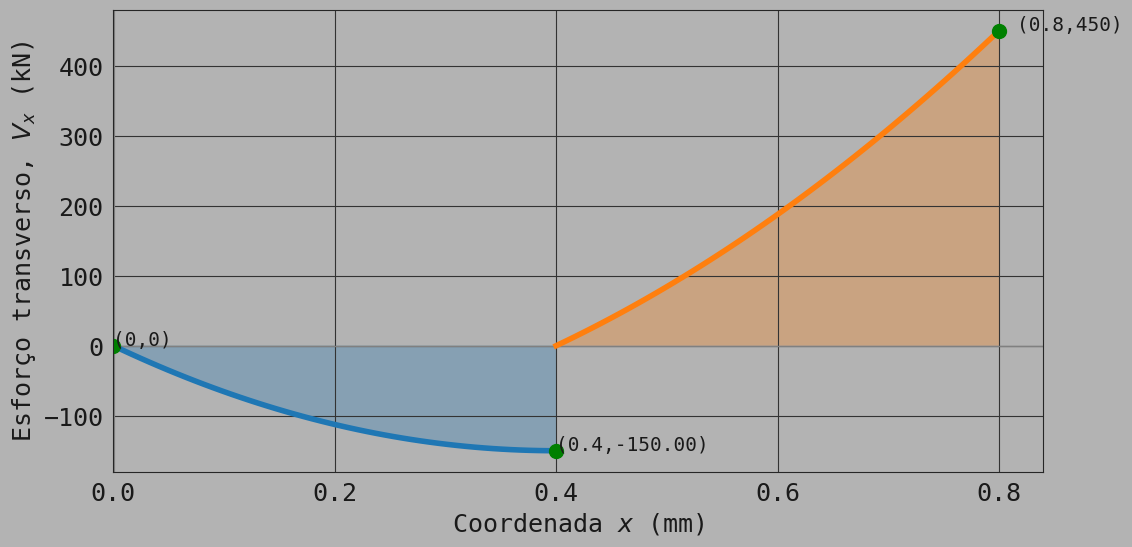

In [61]:
xAB = np.linspace(0,dados.L)
xBC = np.linspace(dados.L,2*dados.L)

def sy2array(sygunc,xlist):
    scalar_func = lambda xx: float(sygunc.evalf(subs={x: xx}))
    vector_func = np.vectorize(scalar_func)
    return vector_func(xlist)

# AB
yVAB, yMAB = sy2array(VAB,xAB), sy2array(MAB,xAB)
# BC
yVBC, yMBC = sy2array(vbc,xBC), sy2array(mbc,xBC)

fz = 14
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=3,color=(.5, .5, .5))
plt.plot(xAB,yVAB,linewidth=4)
plt.fill_between(xAB,yVAB, alpha=.3)
plt.plot(xBC,yVBC,linewidth=4)
plt.fill_between(xBC,yVBC, alpha=.3)
plt.xlabel('Coordenada $x$ (mm)')
plt.ylabel('Esforço transverso, $V_{x}$ (kN)')
plt.plot(xAB[0],yVAB[0],'go',markersize=10)
plt.text(xAB[0],yVAB[0]+.3,f'({xAB[0]:.0f},{yVAB[0]:.0f})',fontsize=fz)
plt.plot(xAB[-1],yVAB[-1],'go',markersize=10)
plt.text(xAB[-1]*1.,yVAB[-1]*1.,f'({xAB[-1]:.1f},{yVAB[-1]:.2f})',
         fontsize=fz)
plt.plot(xBC[-1],yVBC[-1],'go',markersize=10)
plt.text(xBC[-1]*1.02,yVBC[-1]*1.,f'({xBC[-1]:.1f},{yVBC[-1]:.0f})',
         fontsize=fz)
plt.xlim(0,2*dados.L*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.round(np.arange(0,2*dados.L*1.1, 0.2),2)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
# plt.ylim(-int(P4.p2*2),int(P4.p2*2))
plt.grid(True)
plt.show()

#### Diagrama de Momento Fletor

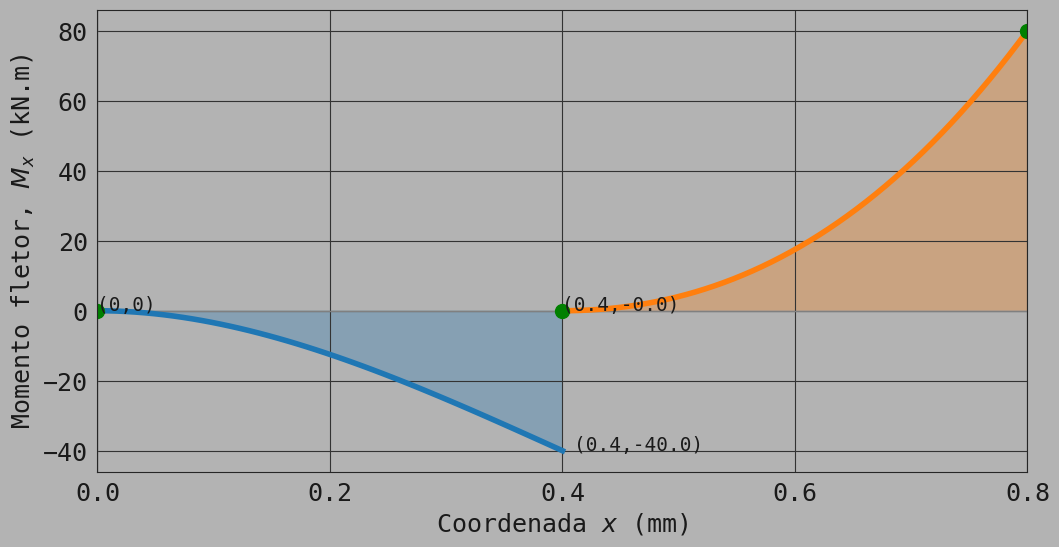

In [51]:
fig, ax = plt.subplots(figsize=(12,6))
plt.axhline(linewidth=1,color=(.5, .5, .5))
plt.axvline(linewidth=1,color=(.5, .5, .5))
plt.plot(xAB,yMAB,linewidth=4)
plt.fill_between(xAB,yMAB, alpha=.3)
plt.plot(xBC,yMBC,linewidth=4)
plt.fill_between(xBC,yMBC, alpha=.3)
plt.xlabel(r'Coordenada $x$ (mm)')
plt.ylabel(r'Momento fletor, $M_{x}$ (kN.m)')
plt.plot(xAB[0],yMAB[0],'go',markersize=10)
plt.text(xAB[0]*1.,yMAB[0],f'({xAB[0]:.0f},{yMAB[0]:.0f})',fontsize=fz)
plt.text(xAB[-1]+.01,yMAB[-1]+.1,f'({xAB[-1]:.1f},{yMAB[-1]:.1f})',fontsize=fz)
plt.plot(xBC[0],yMBC[0],'go',markersize=10)
plt.text(xBC[0]*1.,yMBC[0]*1.,f'({xBC[0]:.1f},{yMBC[0]:.1f})',fontsize=fz)
plt.plot(xBC[-1],yMBC[-1],'go',markersize=10)
plt.xlim(0,dados.L*1.05)
ax.xaxis.set_ticks_position('none')
ax.yaxis.set_ticks_position('none')
# Customize minor tick labels
xrang = np.round(np.arange(0,2*dados.L*1.1, 0.2),2)
ax.set_xticks(xrang)
ax.set_xticklabels([i for i in xrang])
plt.grid(True)
plt.show()

- Tensão normal devido à flexão (Fórmula de Euler):

\begin{equation*}
|\sigma_{xx}| = \frac{M_z}{I_z} y
\quad\wedge\quad  
I_z^\bigcirc = \frac{\pi r⁴}{4}
\quad\wedge\quad  
|\sigma_{xx}^{max}| = \frac{4M_z}{\pi r³}
\end{equation*}


In [52]:
def izcirc(r): return np.pi*r**4/4
Iz = izcirc(dados.d/2)
print(f'Iz = {Iz:3.6e} m⁴ | {Iz*1e12:3.6e} mm⁴')

Iz = 7.853982e-09 m⁴ | 7.853982e+03 mm⁴


In [53]:
Mmax = mbc.subs({(x,dados.L)})
print(f'M Max = {Mmax:.1f} N.m')
ymax = dados.d/2
sigx = Mmax/Iz*ymax
print(f'sigx = {sigx*1e-6:.2f} MPa')

M Max = -0.0 N.m
sigx = -0.00 MPa
